# WM-811K Wafer Map Dataset - Exploratory Data Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

## 1. Load and Inspect the Data

In [3]:
import pickle
import sys

# Patch old pandas module paths for compatibility
# The pickle was saved with pandas < 0.20 which used pandas.indexes.*
_compat_map = {
    'pandas.indexes':         'pandas.core.indexes',
    'pandas.indexes.base':    'pandas.core.indexes.base',
    'pandas.indexes.numeric': 'pandas.core.indexes.base',
    'pandas.indexes.range':   'pandas.core.indexes.range_',
    'pandas.indexes.multi':   'pandas.core.indexes.multi',
    'pandas.indexes.frozen':  'pandas.core.indexes.frozen',
}

for old, new in _compat_map.items():
    try:
        sys.modules[old] = __import__(new, fromlist=[''])
    except ImportError:
        pass

class _CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        for old, new in _compat_map.items():
            if module.startswith(old):
                module = module.replace(old, new, 1)
                break
        return super().find_class(module, name)

# encoding='latin1' is needed for pickles created with Python 2
with open("./Data/LSWMD.pkl", "rb") as f:
    try:
        df = pickle.load(f, encoding='latin1')
    except (ModuleNotFoundError, ImportError):
        f.seek(0)
        df = _CompatUnpickler(f)
        df.encoding = 'latin1'
        df = df.load()

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")
df.head()

/tmp/ipykernel_168384/969649848.py:32: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  df = pickle.load(f, encoding='latin1')


Shape: (811457, 6)

Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']

Dtypes:
waferMap           object
dieSize           float64
lotName            object
waferIndex        float64
trianTestLabel     object
failureType        object
dtype: object


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [4]:
# Stats for key columns — show raw values as stored in the dataset
for col in ['trianTestLabel', 'failureType']:
    print(f"\n{'=' * 50}")
    print(f"Column: {col}")
    print(f"{'=' * 50}")
    print(f"  dtype:    {df[col].dtype}")
    print(f"  non-null: {df[col].notna().sum():,} / {len(df):,}")
    print(f"\n  Sample raw values:")
    for idx in df[col].sample(5, random_state=42).index:
        print(f"    [{idx}]: {repr(df[col].iloc[idx])}")
    print(f"\n  All distinct values (flattened) with counts:")
    flat = df[col].apply(lambda x: repr(x))
    for val, cnt in flat.value_counts().items():
        print(f"    {val:45s}: {cnt:>8,} ({100*cnt/len(df):.1f}%)")


Column: trianTestLabel
  dtype:    object
  non-null: 811,457 / 811,457

  Sample raw values:
    [552336]: array([], shape=(0, 0), dtype=float64)
    [24803]: array([], shape=(0, 0), dtype=float64)
    [426607]: array([], shape=(0, 0), dtype=float64)
    [722885]: array([['Test']], dtype='<U4')
    [192536]: array([], shape=(0, 0), dtype=float64)

  All distinct values (flattened) with counts:
    array([], shape=(0, 0), dtype=float64)       :  638,507 (78.7%)
    array([['Test']], dtype='<U4')               :  118,595 (14.6%)
    array([['Training']], dtype='<U8')           :   54,355 (6.7%)

Column: failureType
  dtype:    object
  non-null: 811,457 / 811,457

  Sample raw values:
    [552336]: array([], shape=(0, 0), dtype=float64)
    [24803]: array([], shape=(0, 0), dtype=float64)
    [426607]: array([], shape=(0, 0), dtype=float64)
    [722885]: array([['none']], dtype='<U4')
    [192536]: array([], shape=(0, 0), dtype=float64)

  All distinct values (flattened) with counts:
  

## 3. Wafer Map 

In [5]:
# Extract failure type labels
# The failureType column typically contains lists like [[label]]
def extract_label(x):
    """Extract the failure type label from the nested structure."""
    if isinstance(x, (list, np.ndarray)):
        # Flatten nested lists/arrays
        flat = np.array(x).flatten()
        if len(flat) > 0:
            return str(flat[0])
    if isinstance(x, str):
        return x
    return "unknown"

df['failure_label'] = df['failureType'].apply(extract_label)

# Count each failure type
label_counts = df['failure_label'].value_counts()

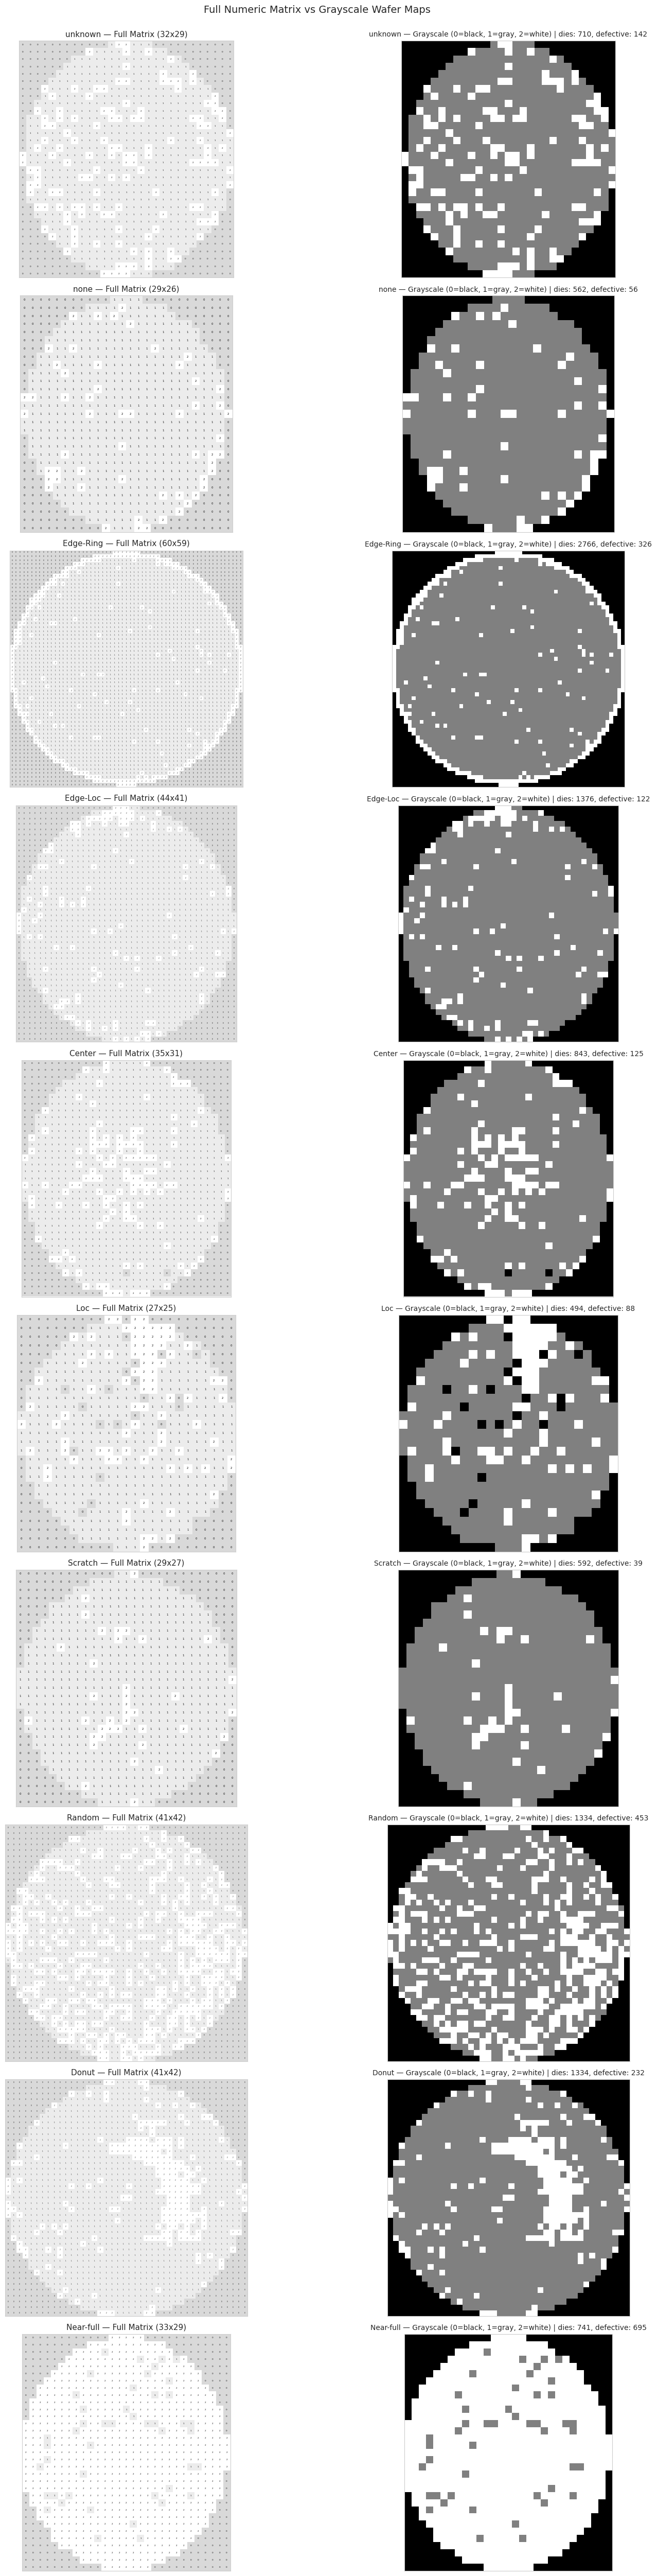

In [6]:
# Plot full numeric matrix grid alongside grayscale wafer map for each failure label
fig, axes = plt.subplots(len(label_counts), 2, figsize=(18, 5 * len(label_counts)))

for i, dtype in enumerate(label_counts.index):
    subset = df[df['failure_label'] == dtype]
    sample = subset.sample(n=1, random_state=42).iloc[0]
    wmap = np.array(sample['waferMap'])
    h, w = wmap.shape

    # Left: full numeric matrix
    ax_num = axes[i, 0]
    ax_num.imshow(wmap, cmap='gray', vmin=0, vmax=2, interpolation='nearest', alpha=0.15)
    fontsize = max(1, min(4, 120 // max(h, w)))
    for row in range(h):
        for col in range(w):
            val = int(wmap[row, col])
            ax_num.text(col, row, str(val), ha='center', va='center', fontsize=fontsize,
                        color='black')
    ax_num.set_title(f"{dtype} — Full Matrix ({h}x{w})", fontsize=11)
    ax_num.set_xticks([])
    ax_num.set_yticks([])

    # Right: grayscale image — 0=black, 1=gray, 2=white
    ax_gray = axes[i, 1]
    ax_gray.imshow(wmap, cmap='gray', vmin=0, vmax=2, interpolation='nearest')
    total = int(np.sum(wmap >= 1))
    defective = int(np.sum(wmap == 2))
    ax_gray.set_title(f"{dtype} — Grayscale (0=black, 1=gray, 2=white) | dies: {total}, defective: {defective}", fontsize=10)
    ax_gray.set_xticks([])
    ax_gray.set_yticks([])

plt.suptitle("Full Numeric Matrix vs Grayscale Wafer Maps", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

Wafer map height — min: 6, max: 300, mean: 45.1, median: 36
Wafer map width  — min: 3, max: 205, mean: 43.1, median: 35


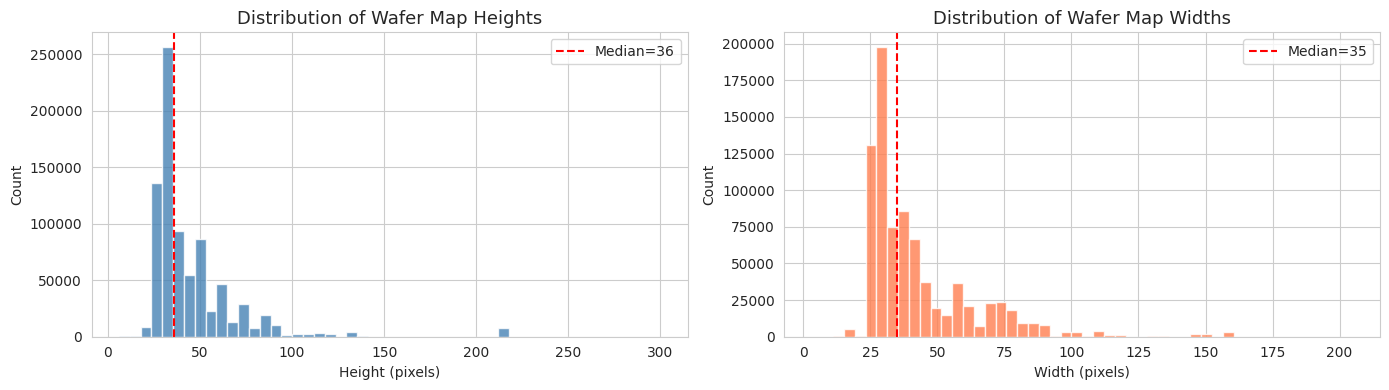

In [7]:
# Analyze wafer map dimensions
# waferMap column contains 2D numpy arrays
valid_maps = df['waferMap'].dropna()

heights = valid_maps.apply(lambda x: x.shape[0] if hasattr(x, 'shape') and len(x.shape) >= 2 else 0)
widths = valid_maps.apply(lambda x: x.shape[1] if hasattr(x, 'shape') and len(x.shape) >= 2 else 0)

print(f"Wafer map height — min: {heights.min()}, max: {heights.max()}, mean: {heights.mean():.1f}, median: {heights.median():.0f}")
print(f"Wafer map width  — min: {widths.min()}, max: {widths.max()}, mean: {widths.mean():.1f}, median: {widths.median():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(heights, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title("Distribution of Wafer Map Heights", fontsize=13)
axes[0].set_xlabel("Height (pixels)")
axes[0].set_ylabel("Count")
axes[0].axvline(heights.median(), color='red', linestyle='--', label=f'Median={heights.median():.0f}')
axes[0].legend()

axes[1].hist(widths, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title("Distribution of Wafer Map Widths", fontsize=13)
axes[1].set_xlabel("Width (pixels)")
axes[1].set_ylabel("Count")
axes[1].axvline(widths.median(), color='red', linestyle='--', label=f'Median={widths.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Sample Wafer Maps by Defect Type

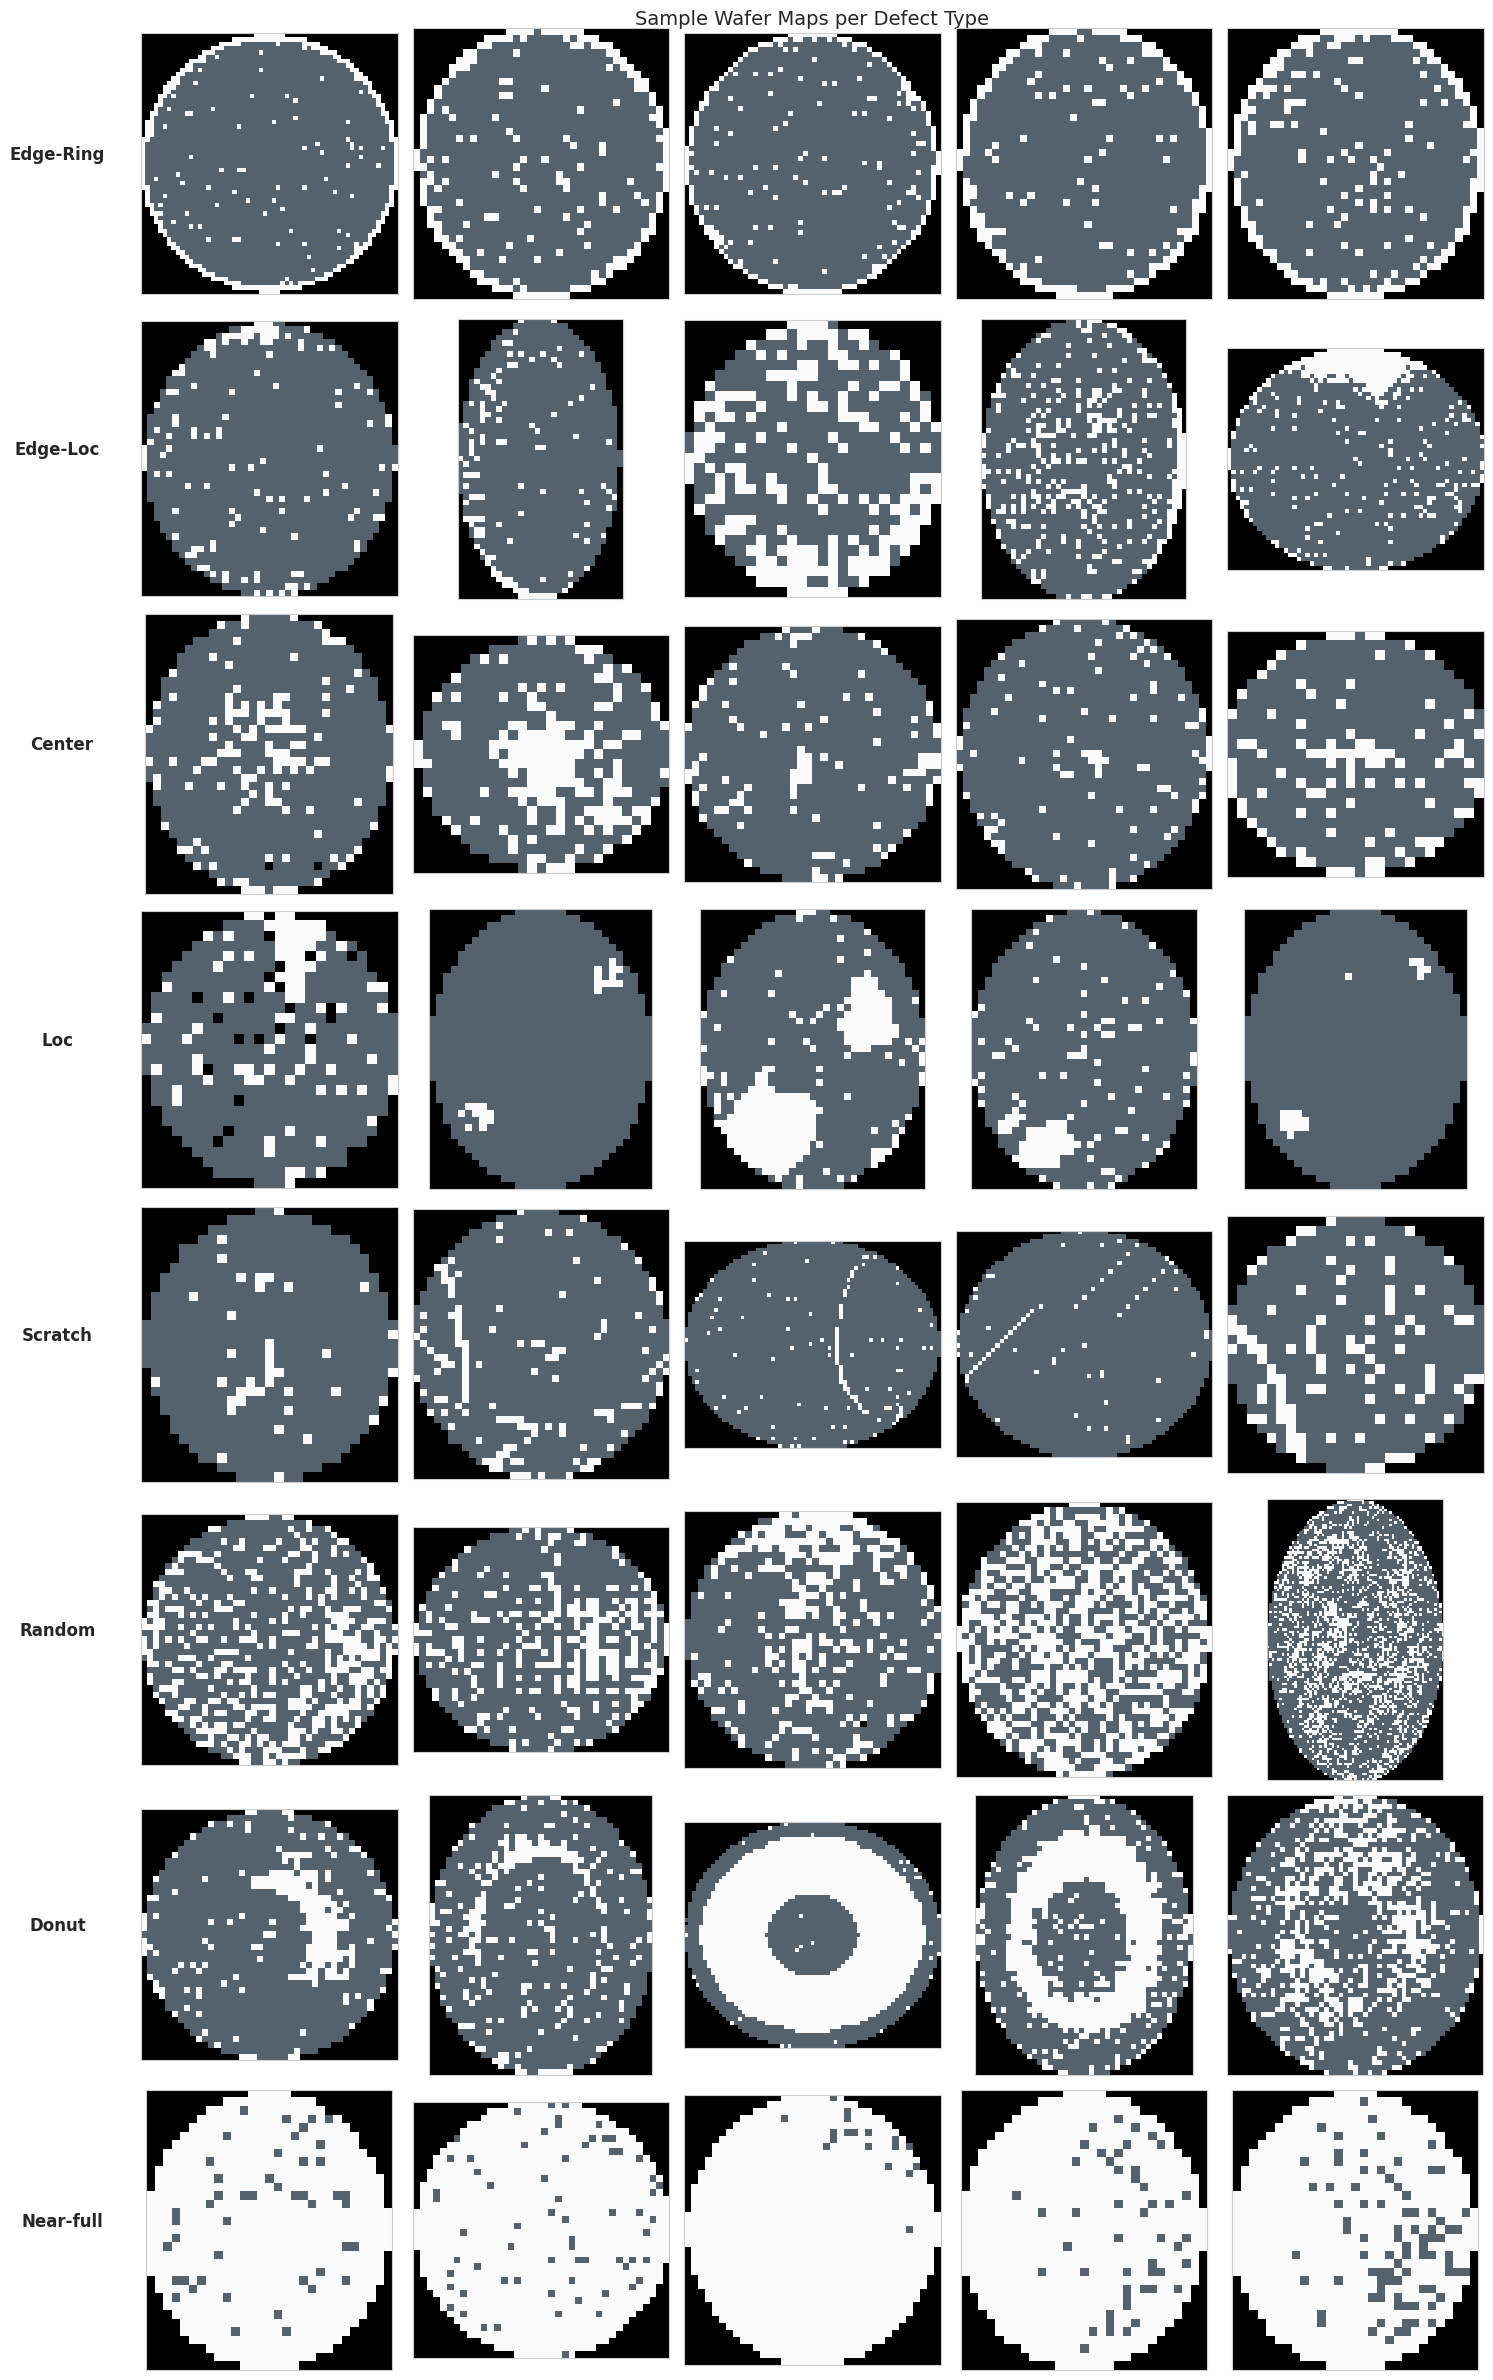

In [8]:
# Visualize sample wafer maps for each defect type
# Pixel values: 0 = background, 1 = normal die, 2 = defective die

# Filter to labeled defect types only (exclude 'none' and 'unknown')
labeled_mask = ~df['failure_label'].isin(['none', 'unknown', ''])
labeled_counts = df.loc[labeled_mask, 'failure_label'].value_counts()

defect_types = labeled_counts.index.tolist()
n_samples = 5

fig, axes = plt.subplots(len(defect_types), n_samples, figsize=(3 * n_samples, 3 * len(defect_types)))

cmap = plt.cm.colors.ListedColormap(['black', '#54626D', '#FAFAFA'])  # bg, normal, defect

for i, dtype in enumerate(defect_types):
    subset = df[df['failure_label'] == dtype]
    samples = subset.sample(n=min(n_samples, len(subset)), random_state=42)

    for j, (_, row) in enumerate(samples.iterrows()):
        ax = axes[i, j] if len(defect_types) > 1 else axes[j]
        wmap = row['waferMap']
        ax.imshow(wmap, cmap=cmap, vmin=0, vmax=2, interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(dtype, fontsize=12, fontweight='bold', rotation=0, labelpad=60)

axes[0, n_samples // 2].set_title("Sample Wafer Maps per Defect Type", fontsize=14) if len(defect_types) > 1 else None
plt.tight_layout()
plt.show()

## 8. Average Defect Heatmaps per Type

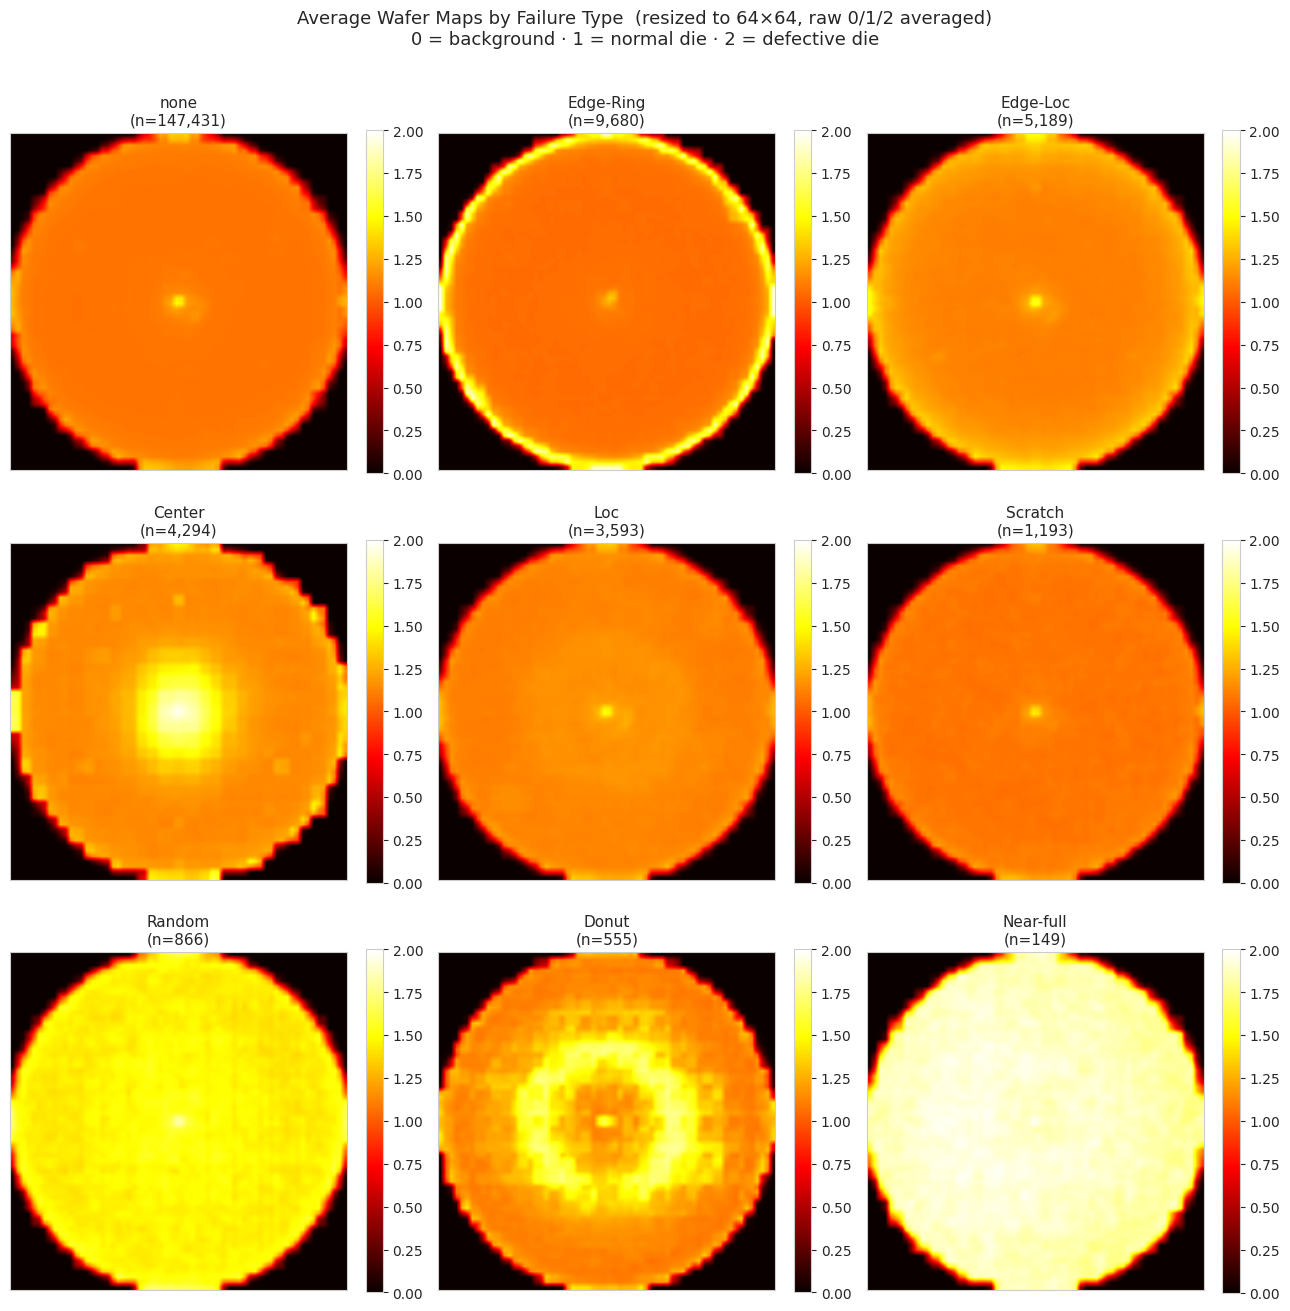

In [9]:
from scipy.ndimage import zoom

TARGET_SIZE = 64

def resize_wafer(wmap, target=TARGET_SIZE):
    if not hasattr(wmap, 'shape') or len(wmap.shape) < 2 or wmap.shape[0] == 0 or wmap.shape[1] == 0:
        return None
    h, w = wmap.shape
    return zoom(wmap, (target / h, target / w), order=0)

# All 9 classes (8 defect types + none), sorted by frequency
all_counts = df.loc[~df['failure_label'].isin(['unknown', '']), 'failure_label'].value_counts()
defect_order = all_counts.index.tolist()   # 9 classes

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
axes = axes.flatten()

for i, dtype in enumerate(defect_order):
    subset = df[df['failure_label'] == dtype]

    heatmap = np.zeros((TARGET_SIZE, TARGET_SIZE))
    count = 0
    for _, row in subset.iterrows():
        resized = resize_wafer(row['waferMap'])
        if resized is not None:
            heatmap += resized.astype(float)
            count += 1

    if count > 0:
        heatmap /= count

    im = axes[i].imshow(heatmap, cmap='hot', interpolation='bilinear', vmin=0, vmax=2)
    axes[i].set_title(f"{dtype}\n(n={count:,})", fontsize=11)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle("Average Wafer Maps by Failure Type  (resized to 64×64, raw 0/1/2 averaged)\n0 = background · 1 = normal die · 2 = defective die", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()